# Exploration des données 2021-2025 : Analyses


### Import si usage Drive

In [1]:
from google.colab import drive
import os
drive.mount('/content/drive')
base_path = '/content/drive/MyDrive/Liora'

# Vérification si le dossier existe et affichage du contenu
if os.path.exists(base_path):
    print("Accès réussi au dossier Liora !")
    print("Contenu du dossier :", os.listdir(base_path))

    # Se déplacer dans ce dossier pour faciliter les imports suivants
    os.chdir(base_path)
else:
    print("Le dossier n'a pas été trouvé. Vérifie bien l'orthographe (majuscules/minuscules) ou si le dossier est dans un sous-dossier.")

Mounted at /content/drive
Accès réussi au dossier Liora !
Contenu du dossier : ['LFB Mobilisation data from January 2009 - 2014.xlsx', 'Mobilisations Metadata.xlsx', 'Incident Metadata.xlsx', 'LFB Incident data from 2024 onwards.xlsx', 'LFB Incident data from 2018 - 2023.xlsx', 'LFB Mobilisation data from 2015 - 2020.xlsx', 'LFB Mobilisation data from 2025.csv', 'LFB Mobilisation data from 2021 - 2024.csv', 'LFB Incident data from 2018 - 2023.csv', 'LFB Incident data from 2024 onwards.csv', 'LFB Mobilisation data from January 2009 - 2014.csv', 'LFB Mobilisation data from 2015 - 2020.csv', 'Metadata Incident_complet.docx', 'Metadata_Mobilisation_complet.docx', 'LFB Incident data from 2009 - 2017.csv', 'all_mobilisations.csv', 'mobilisation_completv26pm.csv', 'Incident_complet.csv', 'incident_complet.csv', 'mobilisation_complet.csv', 'incident_complet_2021_2025.parquet', 'mobilisation_complet_2021_2025.parquet', 'incident_complet.parquet', 'mobilisation_complet.parquet', 'incident_comple

### Import si usage local

In [2]:
base_path = ""

### Import Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
!pip install fastparquet
import plotly.express as px

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 20.9 MB/s eta 0:00:00


### Lecture des fichiers

In [4]:
incident_complet = pd.read_parquet('incident_complet_postcovid_clean.parquet', engine='fastparquet')
mobilisation_complet = pd.read_parquet('mobilisation_complet_postcovid_clean.parquet', engine='fastparquet')

### Incidens : Analyse des temps de réponses par type d'incident

/tmp/ipykernel_2835/702324444.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_all, x='IncidentGroup', y='ResponseTimeMinute',


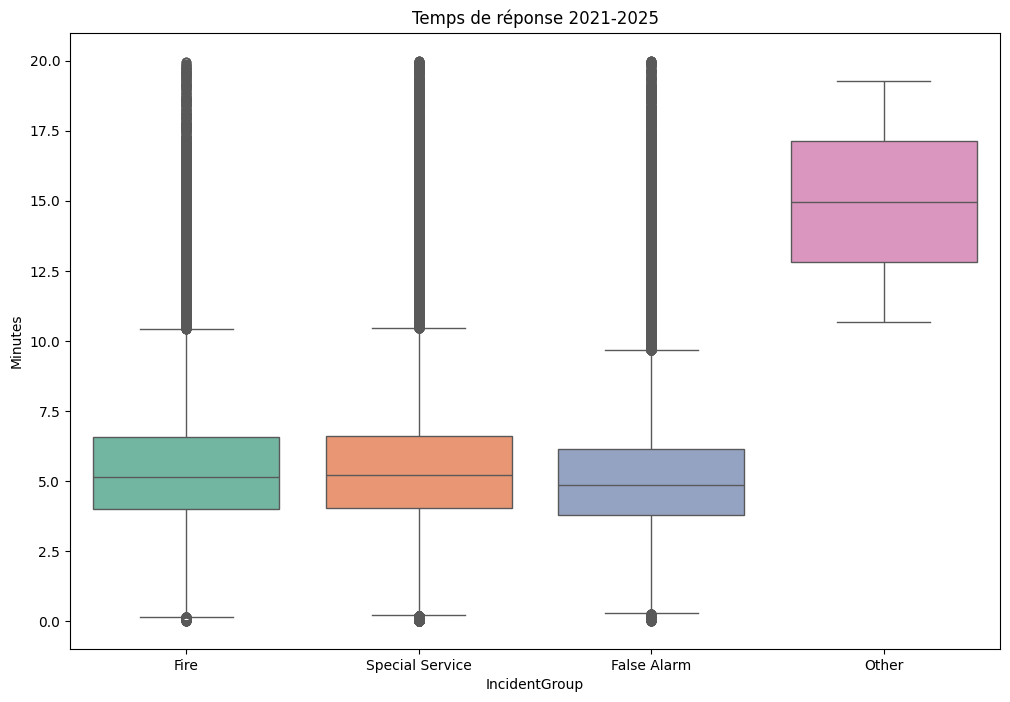

--- Zoom sur les valeurs atypiques ---
                       max       mean     median
IncidentGroup                                   
False Alarm      20.000000   5.167441   4.850000
Fire             19.966667   5.520227   5.150000
Other            19.266667  14.975000  14.975000
Special Service  20.000000   5.495876   5.216667


In [5]:
# Préparation des données (toujours en traitant l'input comme un entier)
incident_complet['FirstPumpArriving_AttendanceTime'] = pd.to_numeric(incident_complet['FirstPumpArriving_AttendanceTime'], errors='coerce')
incident_complet['ResponseTimeMinute'] = incident_complet['FirstPumpArriving_AttendanceTime'] / 60

# Renommage en 'Other' si pas catégories standard
standard_cats = ['Fire', 'Special Service', 'False Alarm']
incident_complet['IncidentGroup'] = incident_complet['IncidentGroup'].apply(
    lambda x: x if x in standard_cats else 'Other'
)

# Nettoyage : valeurs négatives ou nulles
df_all = incident_complet[incident_complet['ResponseTimeMinute'] > 0].copy()

# Visualisation
plt.figure(figsize=(12, 8))
sns.boxplot(data=df_all, x='IncidentGroup', y='ResponseTimeMinute',
            order=['Fire', 'Special Service', 'False Alarm', 'Other'],
            palette='Set2')
plt.title('Temps de réponse 2021-2025')
plt.ylabel('Minutes')
plt.show()

# Analyse des valeurs extrêmes
print("--- Zoom sur les valeurs atypiques ---")
print(df_all.groupby('IncidentGroup')['ResponseTimeMinute'].agg(['max', 'mean', 'median']))

/tmp/ipykernel_2835/1941746416.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=incident_complet,


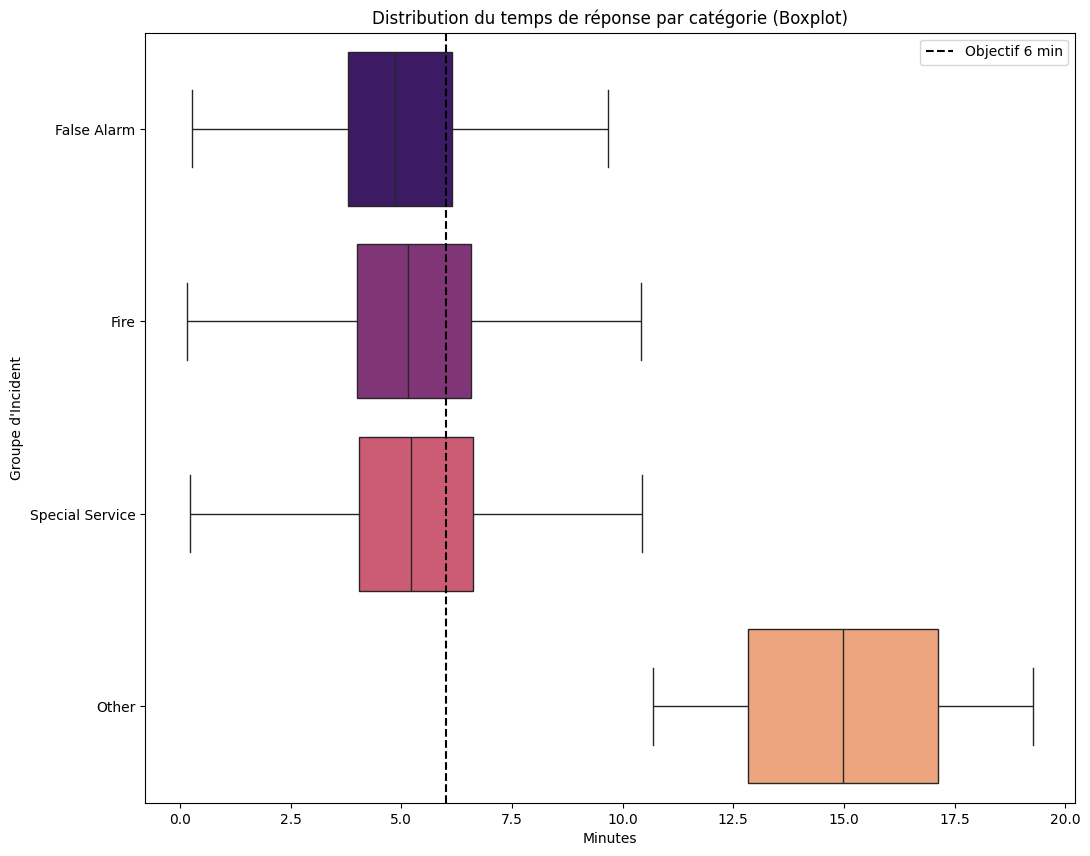

In [6]:
# Nettoyage des données manquantes
incident_complet = incident_complet[incident_complet['IncidentGroup'].notna()]

# Conversion en minutes
incident_complet['AttendanceTimeMin'] = incident_complet['FirstPumpArriving_AttendanceTime'] / 60

plt.figure(figsize=(12, 10))

# Format Boxplot
sns.boxplot(data=incident_complet,
            y='IncidentGroup',
            x='AttendanceTimeMin',
            palette='magma',
            showfliers=False)

# Ligne d'objectif à 6 minutes
plt.axvline(x=6, color='black', linestyle='--', label='Objectif 6 min')

plt.title('Distribution du temps de réponse par catégorie (Boxplot)')
plt.xlabel('Minutes')
plt.ylabel('Groupe d\'Incident')
plt.legend()
plt.show()

### Incidens : Test ANOVA entre temps d'intervention du 1er véhicule et types d'incident

In [7]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

df_anova = incident_complet[
    (incident_complet['FirstPumpArriving_AttendanceTime'] > 0) &
    (incident_complet['FirstPumpArriving_AttendanceTime'] < 1800) # Max 30 min
].copy()


model = ols('FirstPumpArriving_AttendanceTime ~ C(IncidentGroup)', data=df_anova).fit()
anova_table = sm.stats.anova_lm(model, typ=2)

display(anova_table)

,sum_sq,df,F,PR(>F)
C(IncidentGroup),6.133165e+07,3.0,1118.932154,0.0
Residual,1.092433e+10,597909.0,NaN,NaN


### Incidents : Matrice de corrélation pour Incidents

/tmp/ipykernel_2835/1362371409.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_numeric['Hour'] = pd.to_datetime(df_numeric['TimeOfCall']).dt.hour


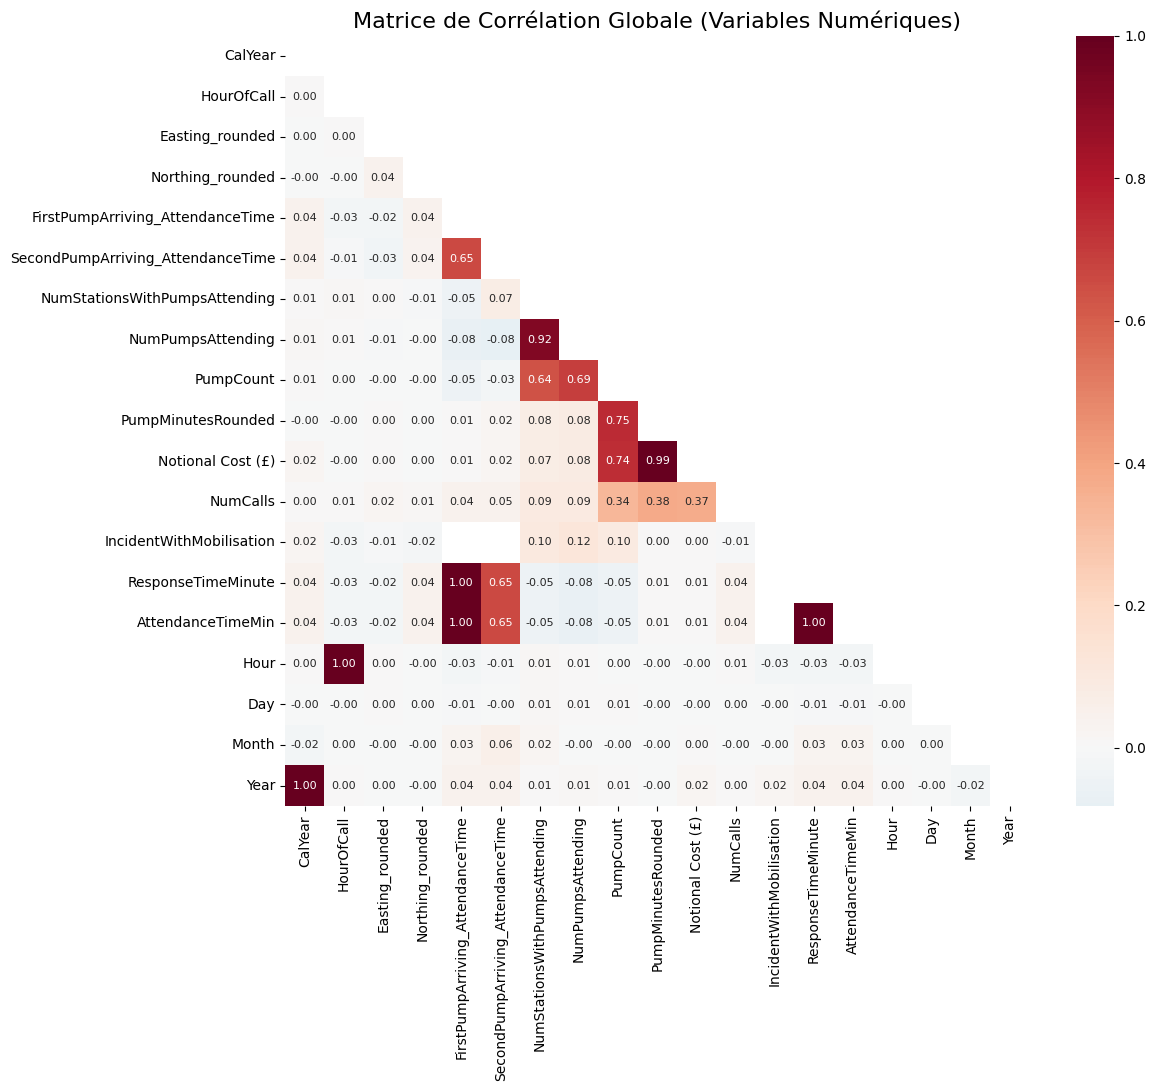

In [8]:
# Extraction des variables temporelles numériques
df_numeric = incident_complet.copy()
df_numeric['Hour'] = pd.to_datetime(df_numeric['TimeOfCall']).dt.hour
df_numeric['Day'] = pd.to_datetime(df_numeric['DateOfCall']).dt.dayofweek
df_numeric['Month'] = pd.to_datetime(df_numeric['DateOfCall']).dt.month
df_numeric['Year'] = pd.to_datetime(df_numeric['DateOfCall']).dt.year

# Compteurs et coordonnées géographiques (Easting/Northing)
cols_to_corr = df_numeric.select_dtypes(include=[np.number]).columns.tolist()

# Suppression colonnes ID ou codes postaux
cols_to_exclude = ['IncidentNumber', 'UPRN', 'USRN']
cols_final = [c for c in cols_to_corr if c not in cols_to_exclude]

# Corrélation
corr_matrix = df_numeric[cols_final].corr()

# Affichage
plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix,
            mask=mask,
            annot=True,
            cmap='RdBu_r',
            fmt=".2f",
            center=0,
            annot_kws={"size": 8})

plt.title('Matrice de Corrélation Globale (Variables Numériques)', fontsize=16)
plt.show()

### Mobilisations : nombre de Mobilisations par types d'incidents

/tmp/ipykernel_2835/3883649386.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


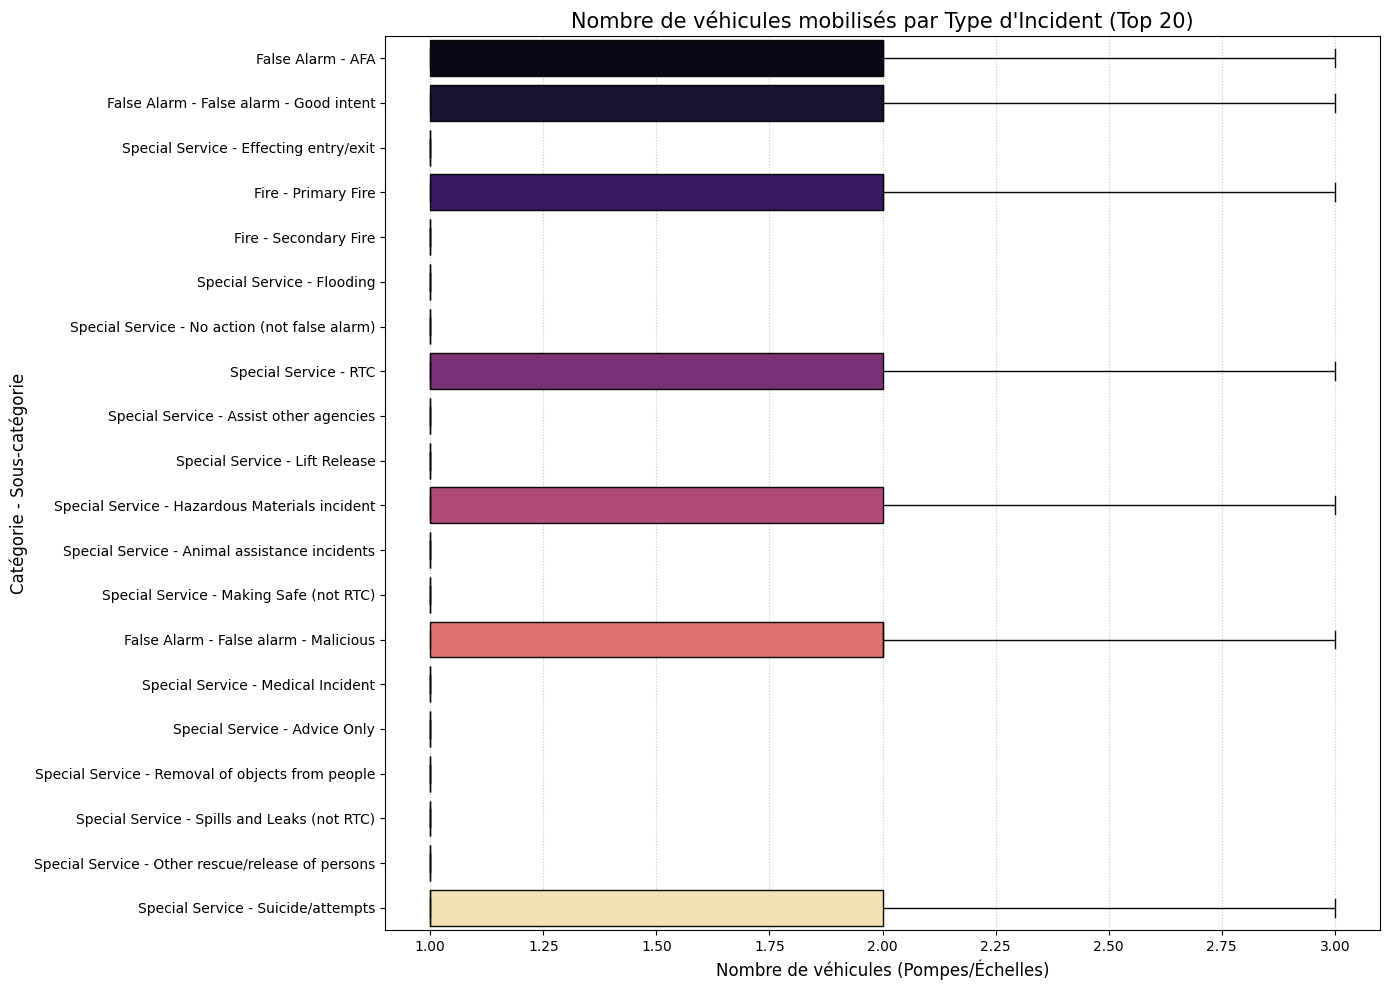

In [9]:
# Catégories dans incident_complet
def get_subcat(row):
    # On récupère le groupe pour éviter de le retaper
    group = row.get('IncidentGroup', 'Other')

    if group in ['False Alarm', 'Fire']:
        return row.get('StopCodeDescription', 'Unknown')
    elif group == 'Special Service':
        # On tente de récupérer SpecialServiceType, sinon on se rabat sur StopCodeDescription
        return row.get('SpecialServiceType', row.get('StopCodeDescription', 'Special Service Other'))
    else:
        return 'Other'

incident_complet['SubCategory'] = incident_complet.apply(get_subcat, axis=1)

# Création des colonnes
incident_complet['SubCategory'] = incident_complet.apply(get_subcat, axis=1)
incident_complet['Full_Type'] = incident_complet['IncidentGroup'] + " - " + incident_complet['SubCategory']

# Agrégation du nombre de ressources par incident : nombre de lignes dans mobilisation_complet pour chaque IncidentNumber
df_counts = mobilisation_complet.groupby('IncidentNumber').size().reset_index(name='Nb_Vehicules_Mobilises')

# Fusion des deux DataFrames
df_final_mobilisations = pd.merge(
    df_counts,
    incident_complet[['IncidentNumber', 'Full_Type']],
    on='IncidentNumber',
    how='inner'
)

# Top 20 pour lisibilité
top_20_types = df_final_mobilisations['Full_Type'].value_counts().head(20).index
df_plot = df_final_mobilisations[df_final_mobilisations['Full_Type'].isin(top_20_types)]

# Visualisation
plt.figure(figsize=(14, 10))

sns.boxplot(
    data=df_plot,
    x='Nb_Vehicules_Mobilises',
    y='Full_Type',
    order=top_20_types,
    palette='magma',
    showfliers=False
)

plt.title('Nombre de véhicules mobilisés par Type d\'Incident (Top 20)', fontsize=15)
plt.xlabel('Nombre de véhicules (Pompes/Échelles)', fontsize=12)
plt.ylabel('Catégorie - Sous-catégorie', fontsize=12)
plt.grid(axis='x', linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()

### Matrice de corrélation

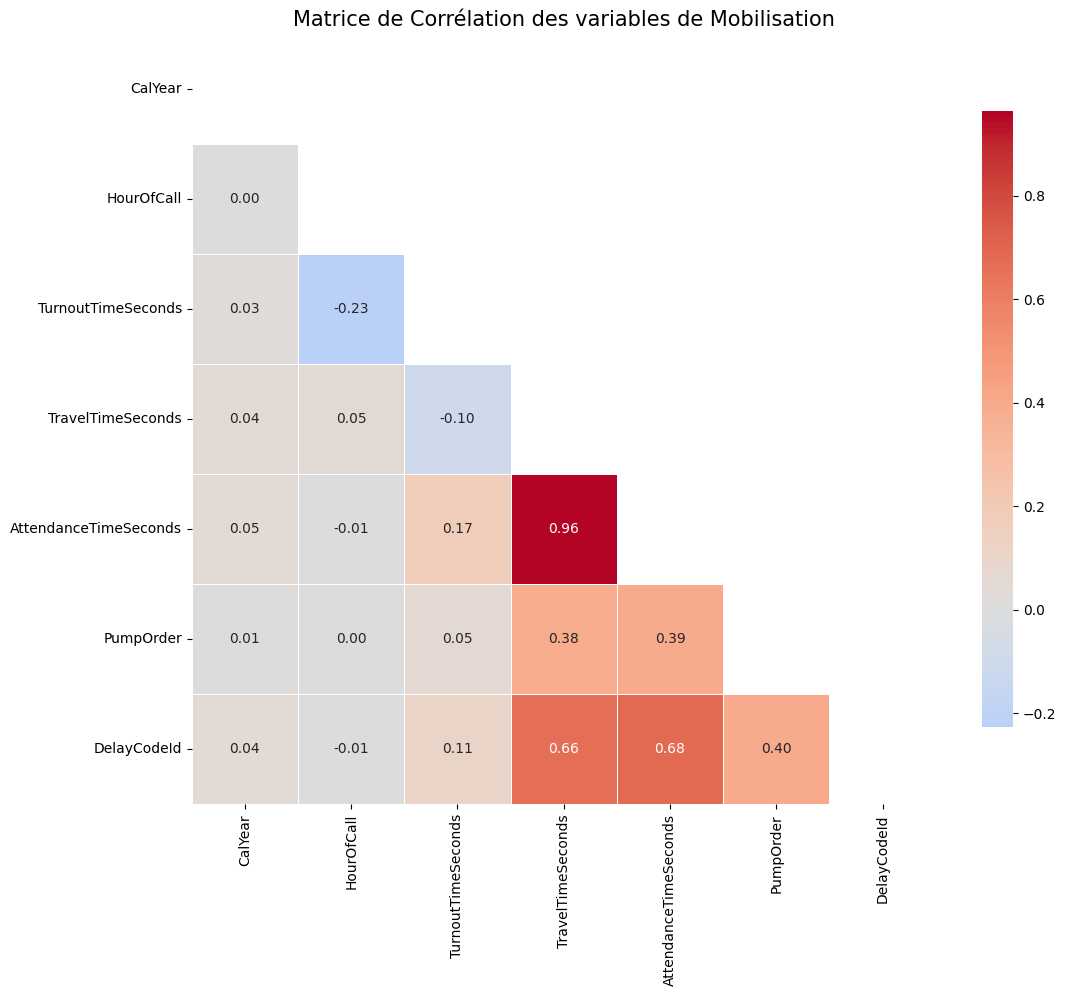

In [10]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Sélection des colonnes numériques
cols_quantitatives = mobilisation_complet.select_dtypes(include=[np.number]).columns.tolist()
cols_a_exclure = ['ResourceMobilisationId', 'IncidentNumber', 'UPRN', 'USRN']
cols_finales = [c for c in cols_quantitatives if c not in cols_a_exclure]

# Corrélation Pearson
corr_mobilisations = mobilisation_complet[cols_finales].corr()

# Visualisation
plt.figure(figsize=(12, 10))

# Masque de  la partie supérieure symétrique
mask = np.triu(np.ones_like(corr_mobilisations, dtype=bool))

sns.heatmap(
    corr_mobilisations,
    mask=mask,
    annot=True,
    fmt=".2f",           # 2 décimales
    cmap='coolwarm',
    center=0,
    linewidths=.5,
    cbar_kws={"shrink": .8}
)

plt.title('Matrice de Corrélation des variables de Mobilisation', fontsize=15)
plt.show()

### Delay code : valeurs de code ID  pour NaN

/tmp/ipykernel_2835/2615078905.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(


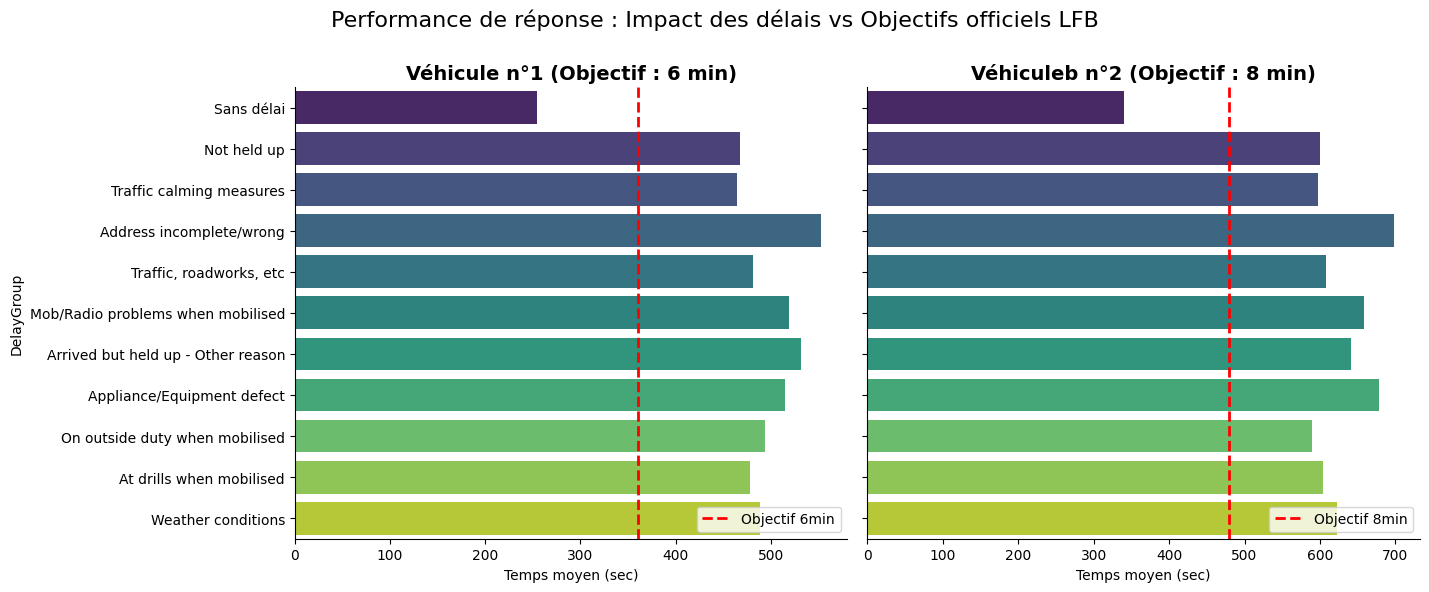

In [11]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Préparation des données
df_plot = mobilisation_complet.copy()
df_plot['DelayGroup'] = df_plot['DelayCode_Description'].fillna('Sans Délai (NULL)')
df_plot = df_plot[df_plot['PumpOrder'] <= 2] # Focus sur les deux premières pompes

# Graphique
g = sns.catplot(
    data=df_plot,
    x='AttendanceTimeSeconds',
    y='DelayGroup',
    col='PumpOrder',
    kind='bar',
    estimator=np.mean,
    errorbar=None,
    palette='viridis',
    height=6,
    aspect=1.2,
    sharex=False # Permet d'ajuster l'échelle X pour la Pompe 2
)

# Application des objectifs spécifiques par pompe
axes = g.axes.flatten()

# Pompe 1 : Objectif 360s
axes[0].axvline(360, color='red', linestyle='--', linewidth=2, label='Objectif 6min')
axes[0].set_title("Véhicule n°1 (Objectif : 6 min)", fontsize=14, fontweight='bold')

# Pompe 2 : Objectif 480s
axes[1].axvline(480, color='red', linestyle='--', linewidth=2, label='Objectif 8min')
axes[1].set_title("Véhiculeb n°2 (Objectif : 8 min)", fontsize=14, fontweight='bold')

# Ajustements
for ax in axes:
    ax.legend(loc='lower right')
    ax.set_xlabel("Temps moyen (sec)")

plt.subplots_adjust(top=0.85)
g.fig.suptitle('Performance de réponse : Impact des délais vs Objectifs officiels LFB', fontsize=16)

plt.show()

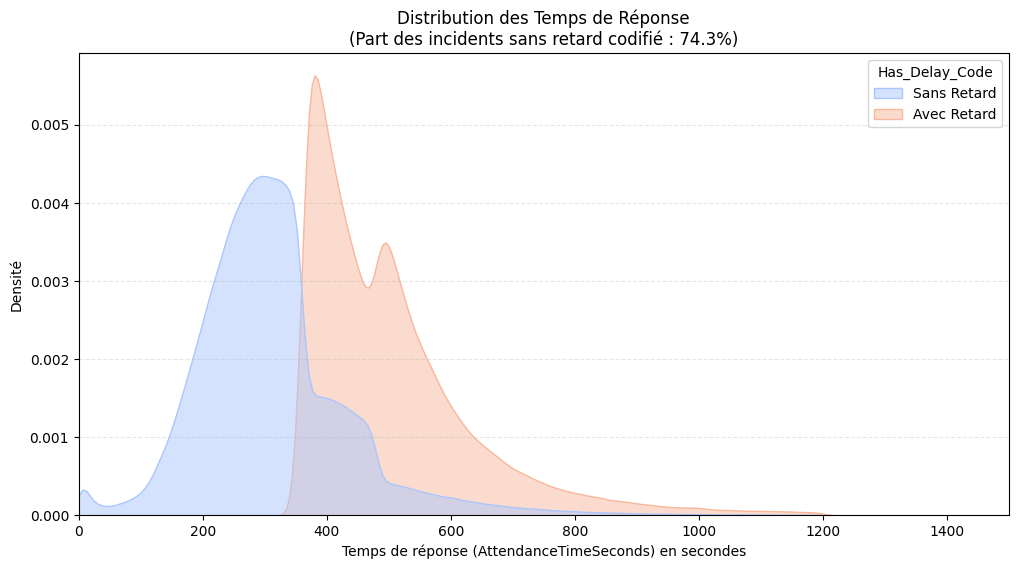

In [12]:
mobilisation_complet = pd.read_parquet('mobilisation_complet_2021_2025.parquet', engine='fastparquet')
# Préparation des données avec colonne temporaire pour identifier si un délai a été saisi
mobilisation_complet['Has_Delay_Code'] = mobilisation_complet['DelayCodeId'].notna().map({True: 'Avec Retard', False: 'Sans Retard'})

# Calcul de la part des retards
part_retard = (mobilisation_complet['DelayCodeId'].isna().sum() / len(mobilisation_complet)) * 100

# Graphique
plt.figure(figsize=(12, 6))

# Distribution du temps d'arrivée pour les deux catégories
sns.kdeplot(data=mobilisation_complet, x='AttendanceTimeSeconds', hue='Has_Delay_Code',
            fill=True, common_norm=False, palette='coolwarm', alpha=0.5)

# Ajustements
plt.title(f'Distribution des Temps de Réponse\n(Part des incidents sans retard codifié : {part_retard:.1f}%)')
plt.xlabel('Temps de réponse (AttendanceTimeSeconds) en secondes')
plt.ylabel('Densité')
plt.xlim(0, 1500)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()

## Saisie des temps par les équipes

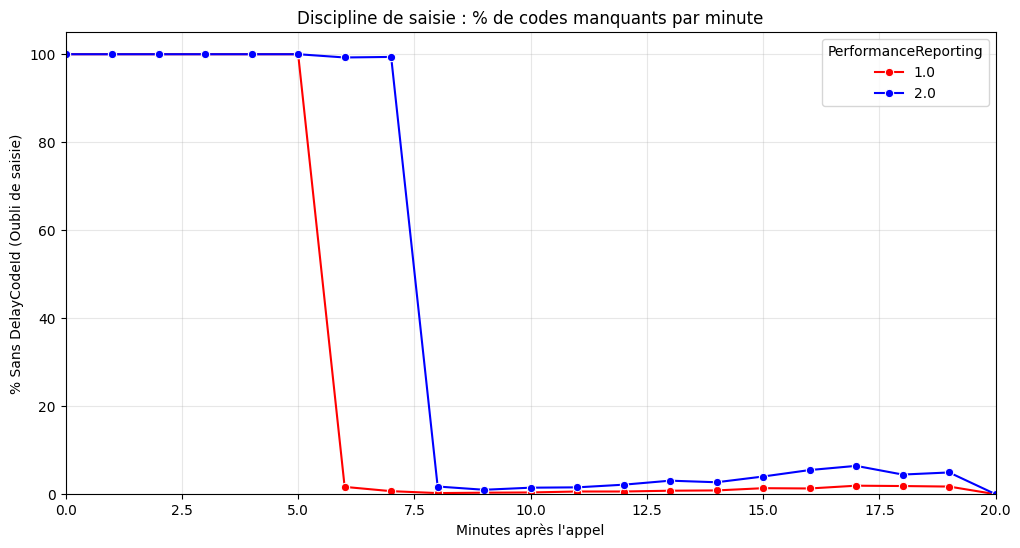

In [13]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Copie des données
df_plot = mobilisation_complet.copy()

# Conversion en numérique (ignore les erreurs avec 'coerce')
df_plot['PerformanceReporting'] = pd.to_numeric(df_plot['PerformanceReporting'], errors='coerce')
df_plot['AttendanceTimeSeconds'] = pd.to_numeric(df_plot['AttendanceTimeSeconds'], errors='coerce')

# Filtrage :  Performance 1 & 2 et les temps > 0 ET < 30 min (1800s)
df_filtered = df_plot[
    (df_plot['PerformanceReporting'].isin([1, 2])) &
    (df_plot['AttendanceTimeSeconds'] > 0) &
    (df_plot['AttendanceTimeSeconds'] < 1800)
].copy()

# Calculs
df_filtered['AttendanceMinutes'] = (df_filtered['AttendanceTimeSeconds'] / 60).astype(int)
df_filtered['Is_Delay_Null'] = df_filtered['DelayCodeId'].isna().astype(int)

# Groupement et calcul du %
stats = df_filtered.groupby(['AttendanceMinutes', 'PerformanceReporting'])['Is_Delay_Null'].mean().reset_index()
stats['%_Sans_Code'] = stats['Is_Delay_Null'] * 100

# Affichage
if stats.empty:
    print("ERREUR : tableau vide. Vérifier les valeurs 'PerformanceReporting'.")
else:
    plt.figure(figsize=(12, 6))
    sns.lineplot(data=stats, x='AttendanceMinutes', y='%_Sans_Code',
                 hue='PerformanceReporting', marker='o', palette={1: 'red', 2: 'blue'})

    plt.title('Discipline de saisie : % de codes manquants par minute')
    plt.ylabel('% Sans DelayCodeId (Oubli de saisie)')
    plt.xlabel('Minutes après l\'appel')
    plt.grid(True, alpha=0.3)
    plt.ylim(0, 105)
    plt.xlim(0, 20)
    plt.show()

## Causes de délais - retards

/tmp/ipykernel_2835/3199067311.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(


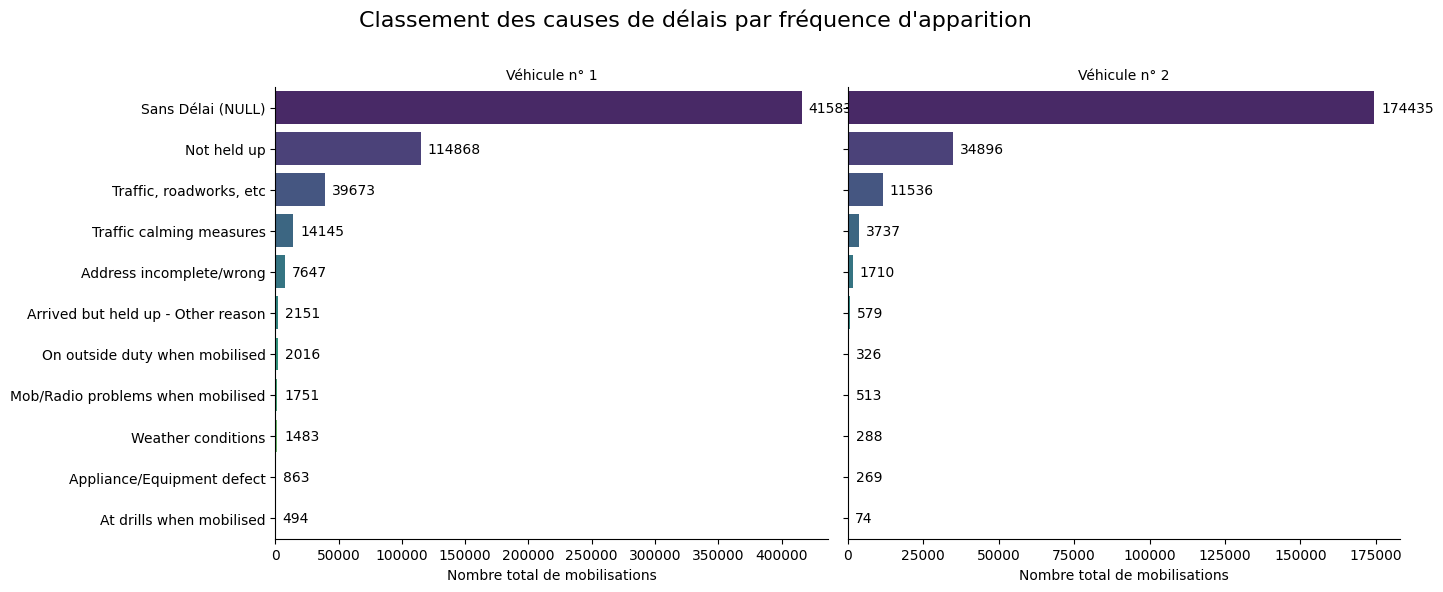

In [14]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Calcul des fréquences
df_vol = mobilisation_complet.copy()
df_vol['DelayGroup'] = df_vol['DelayCode_Description'].fillna('Sans Délai (NULL)')
df_vol = df_vol[df_vol['PumpOrder'] <= 2]

# Calcul de l'ordre global
ordre_frequence = df_vol['DelayGroup'].value_counts().index

# Graphique
g = sns.catplot(
    data=df_vol,
    y='DelayGroup',
    col='PumpOrder',
    kind='count',
    order=ordre_frequence,
    palette='viridis',
    height=6,
    aspect=1.2,
    sharex=False
)

# Ajustements
g.set_titles("Véhicule n° {col_name}")
g.set_axis_labels("Nombre total de mobilisations", "")

for ax in g.axes.flat:
    # On ajoute les labels de données pour la précision
    for p in ax.patches:
        width = p.get_width()
        if width > 0:
            ax.annotate(f'{int(width)}',
                        (width, p.get_y() + p.get_height() / 2),
                        ha='left', va='center', fontsize=10, xytext=(5, 0),
                        textcoords='offset points')

plt.subplots_adjust(top=0.85)
g.fig.suptitle('Classement des causes de délais par fréquence d\'apparition', fontsize=16)

plt.show()

### Check de DelayCodeId NaN

In [15]:
#Check de DelayCodeId NaN

mobilisation_complet[
    (mobilisation_complet["TravelTimeSeconds"] > 0) &
    (mobilisation_complet["DelayCodeId"].isna())
].groupby("PumpOrder").size()


,0
PumpOrder,
1,412052
2,173845
3,47893
4,29865
5,21621
6,1164
7,143
8,32
9,5


### Sources de retards par véhicule (pompe)

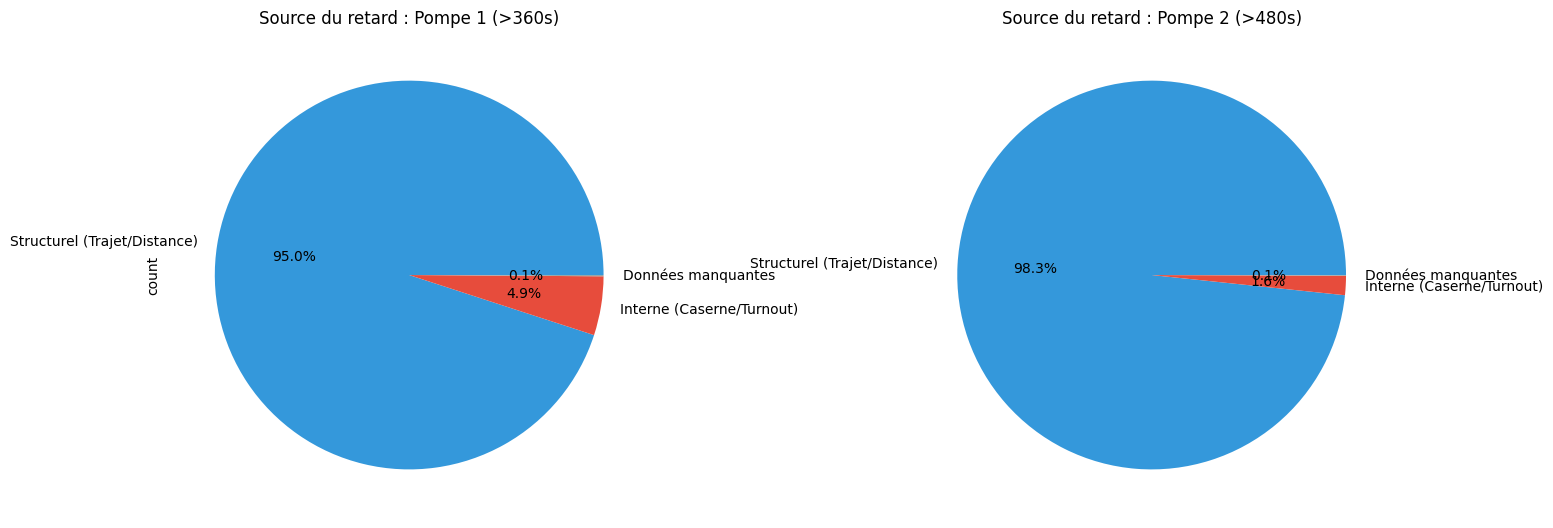

In [16]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Création d'un masque
mask_not_held_up = mobilisation_complet['DelayCode_Description'].fillna('Not held up') == 'Not held up'

# Filtrage du DataFrame
df_clean = mobilisation_complet[mask_not_held_up].copy()

# Calcul des références sans les NA (médianes sur les réussites)
ref_turnout = mobilisation_complet[mobilisation_complet['AttendanceTimeSeconds'] <= 360]['TurnoutTimeSeconds'].median()
ref_travel = mobilisation_complet[mobilisation_complet['AttendanceTimeSeconds'] <= 360]['TravelTimeSeconds'].median()

# Fonction de diagnostic
def diagnostiquer_source(row):
    # Si l'une des valeurs est manquante, on ne peut pas comparer
    if pd.isna(row['TurnoutTimeSeconds']) or pd.isna(row['TravelTimeSeconds']):
        return 'Données manquantes'

    # Calcul du surplus par rapport à la normale
    diff_turnout = row['TurnoutTimeSeconds'] - ref_turnout
    diff_travel = row['TravelTimeSeconds'] - ref_travel

    # On compare quel pôle a généré le plus de "surplus"
    if diff_turnout > diff_travel:
        return 'Interne (Caserne/Turnout)'
    else:
        return 'Structurel (Trajet/Distance)'

# Application du diagnostic
df_p1_fail = df_clean[(df_clean['PumpOrder'] == 1) & (df_clean['AttendanceTimeSeconds'] > 360)].copy()
df_p2_fail = df_clean[(df_clean['PumpOrder'] == 2) & (df_clean['AttendanceTimeSeconds'] > 480)].copy()

# Utilisation de apply seulement si le dataframe n'est pas vide
if not df_p1_fail.empty:
    df_p1_fail['Source'] = df_p1_fail.apply(diagnostiquer_source, axis=1)

if not df_p2_fail.empty:
    df_p2_fail['Source'] = df_p2_fail.apply(diagnostiquer_source, axis=1)

# Visualisation
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

if not df_p1_fail.empty and 'Source' in df_p1_fail:
    df_p1_fail['Source'].value_counts().plot(kind='pie', ax=ax1, autopct='%1.1f%%', colors=['#3498DB', '#E74C3C', '#95A5A6'])
    ax1.set_title("Source du retard : Pompe 1 (>360s)")

if not df_p2_fail.empty and 'Source' in df_p2_fail:
    df_p2_fail['Source'].value_counts().plot(kind='pie', ax=ax2, autopct='%1.1f%%', colors=['#3498DB', '#E74C3C', '#95A5A6'])
    ax2.set_title("Source du retard : Pompe 2 (>480s)")

plt.ylabel("")
plt.tight_layout()
plt.show()

### Impact du nettoyage des données sur la diustribution des codes retards DelayCodeID

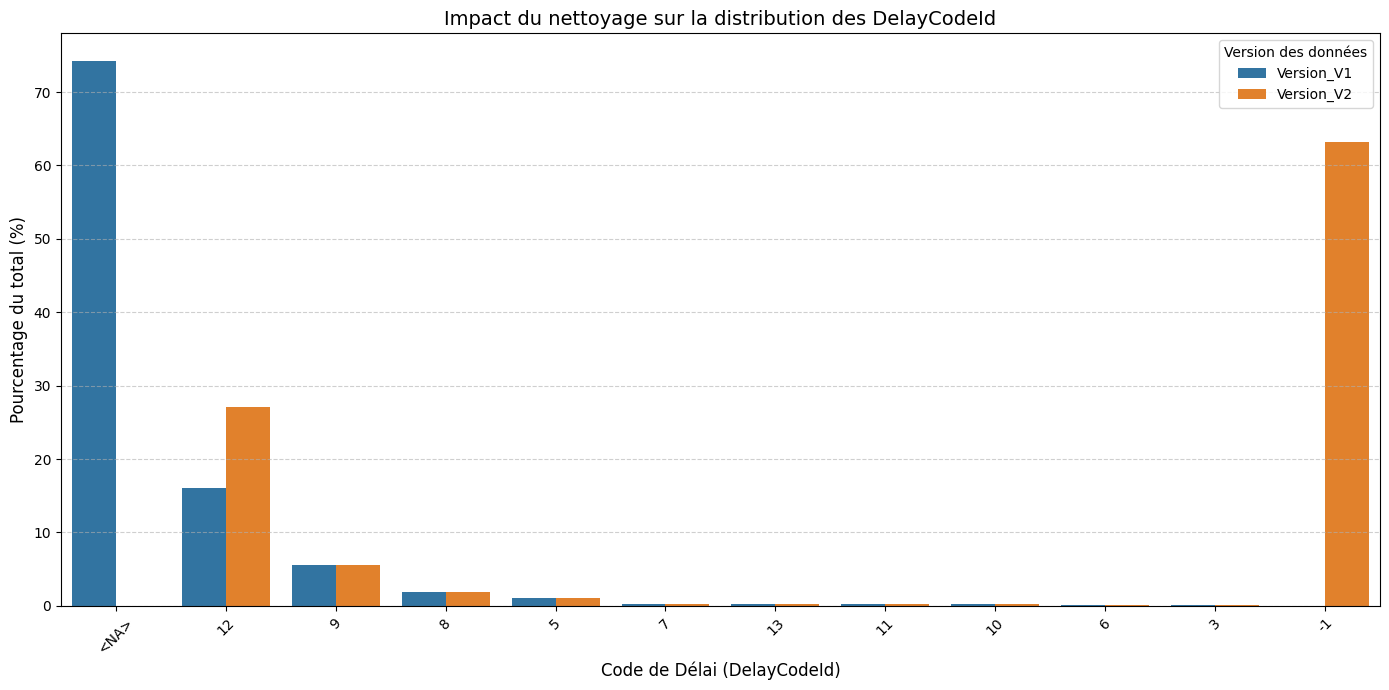

,DelayCodeId
count,239362.0
mean,10.662749
std,1.987854
min,3.0
25%,9.0
50%,12.0
75%,12.0
max,13.0


,CalYear,HourOfCall,ResourceMobilisationId,DateAndTimeMobilised,DateAndTimeMobile,DateAndTimeArrived,TurnoutTimeSeconds,TravelTimeSeconds,AttendanceTimeSeconds,DateAndTimeLeft,PumpOrder,DelayCodeId
count,930521.0,930521.0,930521.0,930521,930521,930521,930521.0,930521.0,930521.0,930144,930521.0,930521.000000
mean,2023.121642,13.347161,6467576.821039,2023-08-21 02:25:24.618659584,2023-08-21 02:26:38.967219968,2023-08-21 02:31:25.661430528,74.374054,287.59647,361.970238,2023-08-21 02:41:59.910078720,1.546318,3.434107
min,2021.0,0.0,5769249.0,2021-01-01 00:06:00,2021-01-01 00:07:00,2021-01-01 00:09:00,0.0,0.0,1.0,2021-01-01 00:18:00,1.0,-1.000000
25%,2022.0,9.0,6108673.0,2022-06-10 22:10:00,2022-06-10 22:11:00,2022-06-10 22:13:00,52.0,186.0,260.0,2022-06-10 22:59:30,1.0,-1.000000
50%,2023.0,14.0,6461330.0,2023-09-12 20:53:00,2023-09-12 20:54:00,2023-09-12 21:00:00,71.0,264.0,339.0,2023-09-12 21:02:00,1.0,-1.000000
75%,2024.0,19.0,6818943.0,2024-11-12 21:08:00,2024-11-12 21:10:00,2024-11-12 21:13:00,91.0,360.0,436.0,2024-11-12 20:55:15,2.0,12.000000
max,2025.0,23.0,7196962.0,2025-12-31 23:57:00,2025-12-31 23:58:00,2026-01-01 00:04:00,1192.0,1187.0,1200.0,2026-01-01 02:11:00,13.0,13.000000
std,1.401526,6.423703,411778.032309,NaN,NaN,NaN,41.065867,151.056034,152.618959,NaN,0.925146,5.914961


In [17]:

v1 = pd.read_parquet('mobilisation_complet_2021_2025.parquet', engine='fastparquet')
v2 = pd.read_parquet('mobilisation_complet_postcovid_clean.parquet', engine='fastparquet')


# 2. Calcul des distributions
dist_v1 = v1['DelayCodeId'].value_counts(dropna=False).rename('v1_count')
dist_v2 = v2['DelayCodeId'].value_counts(dropna=False).rename('v2_count')

# 3. Fusion et calcul des pourcentages
df_comp = pd.concat([dist_v1, dist_v2], axis=1).fillna(0)
df_comp['v1_pct'] = (df_comp['v1_count'] / len(v1) * 100).round(2)
df_comp['v2_pct'] = (df_comp['v2_count'] / len(v2) * 100).round(2)

# On réinitialise l'index et on renomme explicitement la colonne créée 'DelayCodeId'
df_plot_prep = df_comp[['v1_pct', 'v2_pct']].reset_index()
df_plot_prep.columns = ['DelayCodeId', 'Version_V1', 'Version_V2']

# On utilise melt sur les nouveaux noms de colonnes
df_plot = df_plot_prep.melt(id_vars='DelayCodeId',
                            value_vars=['Version_V1', 'Version_V2'],
                            var_name='Dataset',
                            value_name='Percentage')

# Nettoyage des labels pour le graphique
df_plot['DelayCodeId'] = df_plot['DelayCodeId'].astype(str).replace('nan', 'NaN (Manquant)')

# Visualisation
plt.figure(figsize=(14, 7))
sns.barplot(data=df_plot, x='DelayCodeId', y='Percentage', hue='Dataset')

plt.title('Impact du nettoyage sur la distribution des DelayCodeId', fontsize=14)
plt.xlabel('Code de Délai (DelayCodeId)', fontsize=12)
plt.ylabel('Pourcentage du total (%)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.legend(title='Version des données')
plt.tight_layout()

plt.show()
display(v1['DelayCodeId'].describe())
display(v2.describe())

### Carte des incidents

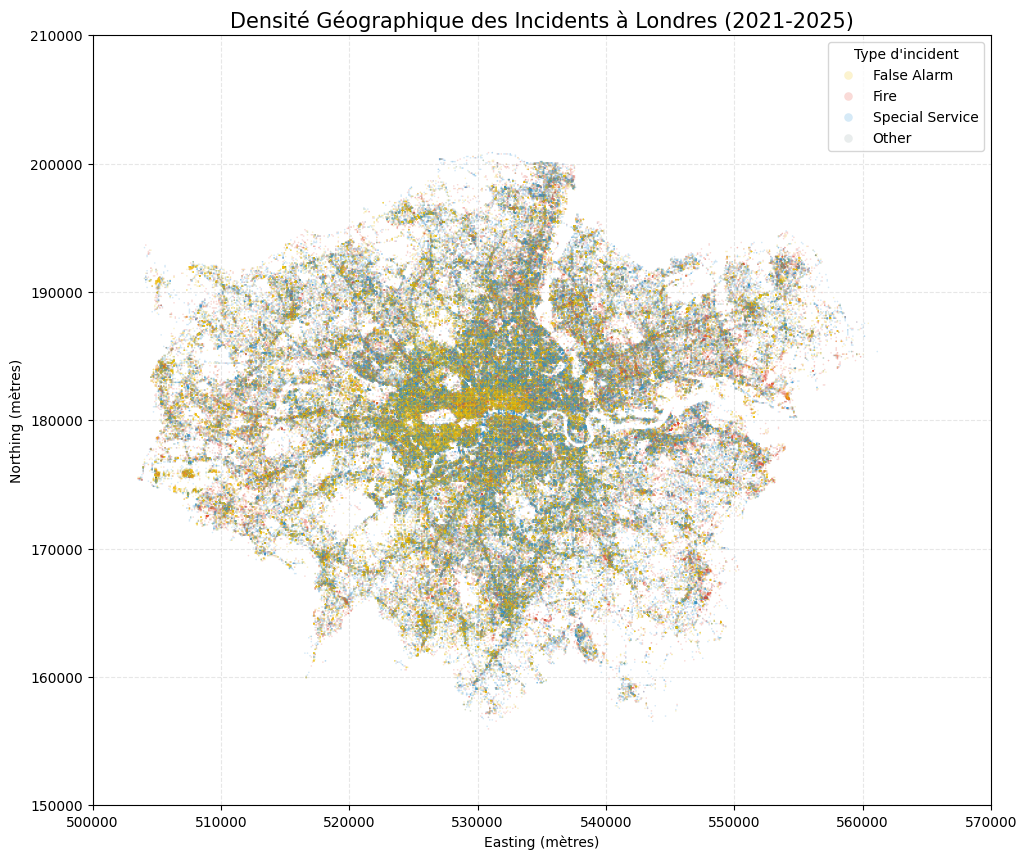

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Enlever les NaN pour éviter les erreurs de placement
df_map = incident_complet.dropna(subset=['Easting_rounded', 'Northing_rounded']).copy()

# couleurs prioritaires
palette_colors = {
    'Fire': '#E74C3C',
    'False Alarm': '#F1C40F',
    'Special Service': '#3498DB'
}

# 'Other' ou autre catégorie en Gris
unique_groups = df_map['IncidentGroup'].unique()
for group in unique_groups:
    if group not in palette_colors:
        palette_colors[group] = '#95A5A6' # Gris pour les catégories secondaires

# Graphique
fig, ax = plt.subplots(figsize=(12, 10))

sns.scatterplot(
    data=df_map,
    x='Easting_rounded',
    y='Northing_rounded',
    hue='IncidentGroup',
    palette=palette_colors,
    s=1,
    alpha=0.2,
    edgecolor=None,
    ax=ax
)

# Ajustements
ax.set_title('Densité Géographique des Incidents à Londres (2021-2025)', fontsize=15)
ax.set_xlabel('Easting (mètres)')
ax.set_ylabel('Northing (mètres)')
ax.legend(title='Type d\'incident', markerscale=6, loc='upper right')
ax.grid(True, linestyle='--', alpha=0.3)
ax.set_xlim(500000, 570000)
ax.set_ylim(150000, 210000)

# Garder les proportions réelles de la carte
ax.set_aspect('equal', 'box')

plt.show()



### Check Incidents sans mobilisations


In [19]:
incidents_sans_station = incident_complet[incident_complet['FirstPumpArriving_DeployedFromStation']=='']
display(incidents_sans_station.info())
#display(incident_complet.info())
#display(incident_complet.head())
#display(incidents_sans_station.head())
display(incidents_sans_station.describe())

<class 'pandas.core.frame.DataFrame'>
Index: 35268 entries, 69 to 633168
Data columns (total 35 columns):
 #   Column                                  Non-Null Count  Dtype         
---  ------                                  --------------  -----         
 0   IncidentNumber                          35268 non-null  object        
 1   DateOfCall                              35268 non-null  datetime64[ns]
 2   CalYear                                 35268 non-null  int64         
 3   TimeOfCall                              35268 non-null  object        
 4   HourOfCall                              35268 non-null  int64         
 5   IncidentGroup                           35268 non-null  object        
 6   StopCodeDescription                     35268 non-null  object        
 7   PropertyCategory                        35268 non-null  object        
 8   PropertyType                            35268 non-null  object        
 9   AddressQualifier                        35268 non-nul

None

,DateOfCall,CalYear,HourOfCall,USRN,Easting_rounded,Northing_rounded,FirstPumpArriving_AttendanceTime,SecondPumpArriving_AttendanceTime,NumStationsWithPumpsAttending,NumPumpsAttending,PumpCount,PumpMinutesRounded,Notional Cost (£),NumCalls,IncidentWithMobilisation,ResponseTimeMinute,AttendanceTimeMin
count,35268,35268.000000,35268.000000,35268.0,35268.000000,35268.000000,3.000000,2.00000,26777.000000,26777.000000,35268.000000,35268.000000,35268.000000,35265.000000,35268.000000,3.000000,3.000000
mean,2023-06-30 04:04:00.081660160,2022.975360,14.039866,20541286.64611,530960.865374,180873.766587,98.666667,397.00000,1.019158,1.029503,1.037711,70.999064,462.717109,1.378477,0.000085,1.644444,1.644444
min,2021-01-01 00:00:00,2021.000000,0.000000,8100010.0,503650.000000,156850.000000,2.000000,369.00000,1.000000,1.000000,1.000000,60.000000,346.000000,1.000000,0.000000,0.033333,0.033333
25%,2022-03-09 00:00:00,2022.000000,10.000000,20500132.0,525950.000000,177650.000000,49.500000,383.00000,1.000000,1.000000,1.000000,60.000000,364.000000,1.000000,0.000000,0.825000,0.825000
50%,2023-06-16 00:00:00,2023.000000,15.000000,21301604.0,531250.000000,181250.000000,97.000000,397.00000,1.000000,1.000000,1.000000,60.000000,388.000000,1.000000,0.000000,1.616667,1.616667
75%,2024-10-12 00:00:00,2024.000000,19.000000,22200637.0,535750.000000,184650.000000,147.000000,411.00000,1.000000,1.000000,1.000000,60.000000,430.000000,2.000000,0.000000,2.450000,2.450000
max,2025-12-31 00:00:00,2025.000000,23.000000,99990116.0,611150.000000,302450.000000,197.000000,425.00000,6.000000,7.000000,38.000000,20369.000000,119498.000000,103.000000,1.000000,3.283333,3.283333
std,NaN,1.442124,5.892752,5850136.436632,9050.569793,6682.738208,97.510683,39.59798,0.184268,0.223932,0.406648,137.618313,834.372433,1.281095,0.009223,1.625178,1.625178


### Pairplot pour explorer relations entre nombre de véhicules, temps d'arrivée et type d'incident

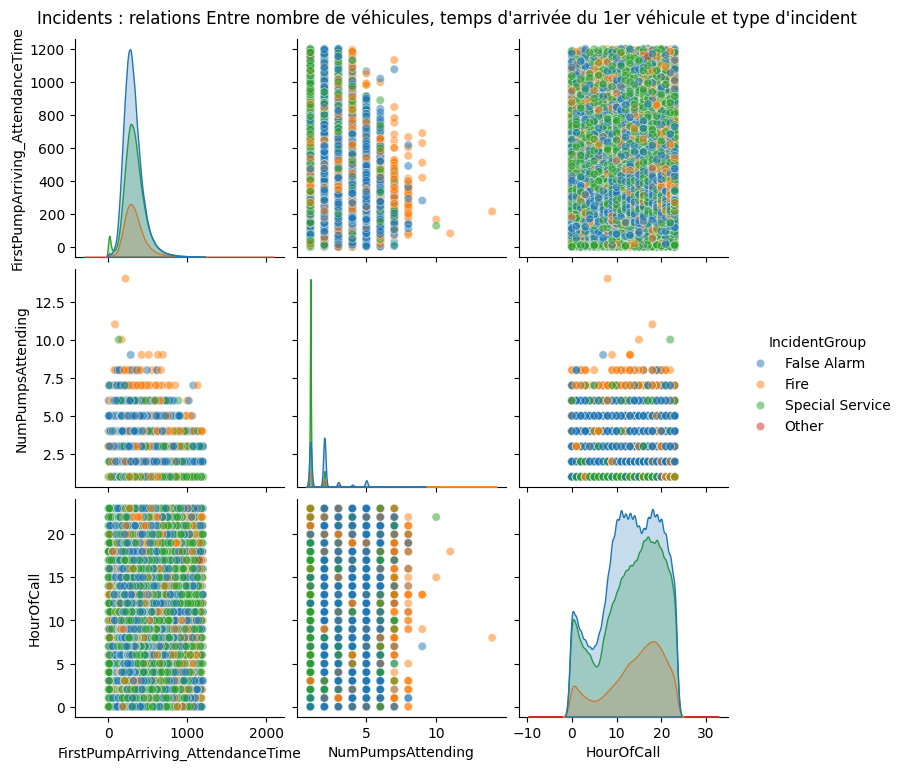

In [20]:
cols_incident = ['FirstPumpArriving_AttendanceTime', 'NumPumpsAttending', 'HourOfCall', 'IncidentGroup']
sns.pairplot(incident_complet[cols_incident],
             diag_kind='kde',
             plot_kws={'alpha': 0.5},
             hue='IncidentGroup',
             )
plt.suptitle("Incidents : relations Entre nombre de véhicules, temps d'arrivée du 1er véhicule et type d'incident", y=1.02)
plt.show()


### Pairplot pour explorer relations entre temps de réponse et heure de mobilisation

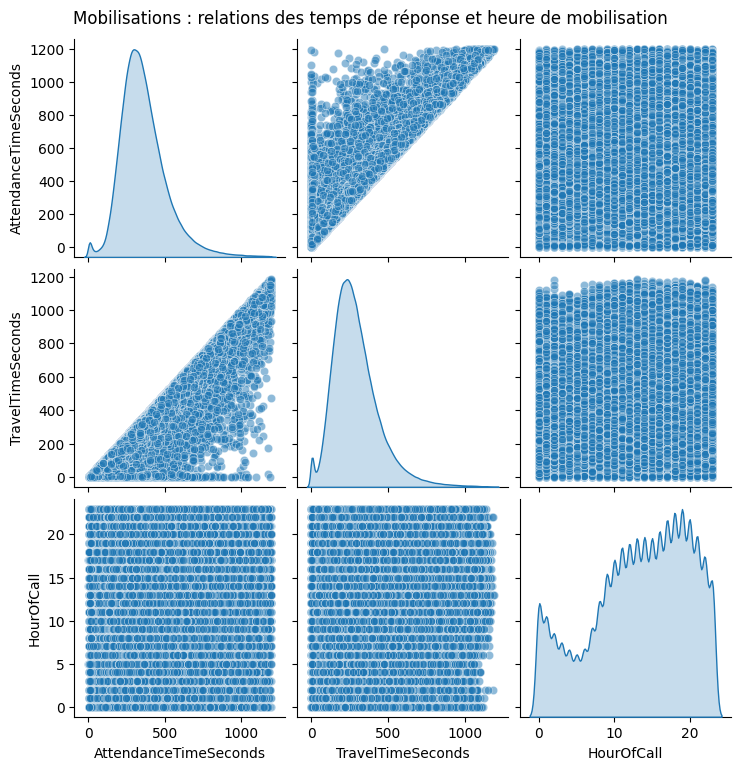

In [21]:
# Pairplot pour mobilisations
cols_mob = ['AttendanceTimeSeconds', 'TravelTimeSeconds', 'HourOfCall']
sns.pairplot(mobilisation_complet[cols_mob],
             diag_kind='kde',
             plot_kws={'alpha': 0.5}, # Transparence car beaucoup de points
             #palette='magma'
             )

plt.suptitle("Mobilisations : relations des temps de réponse et heure de mobilisation", y=1.02)
plt.show()